## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** William Keenan

**Date:** 9/27/2026

1. The difference between regression and classification is the type of outcome that each results in. Both are supervised learning, with regression predicting a numeric, continuous outcome (like a price for a house or a temperature), while classification predicts a categorical outcome. Regression's "how wrong" is a matter of distance, while classification is either in the right or wrong category.

2. A confusion table is a scorecard that compares what the model guessed with what is actually true. The correct guesses sit on the diagonal and everything else is a mistake. Its value is that it shows what kind of mistakes the model makes. "90% accurate" sounds great until the table shows that nearly all the errors happen in one category that you might "care" the most about or is most important.

3. The SSE adds up how far off each prediction was, after squaring each miss. A small SSE meaans that the prediction was pretty close to the real values. Squaring the miss just increases the severity of a large miss, since for example missing by 10 will have an SSE of 100, but missing by 2 will have an SSE of 4.

4. Overfitting is the equivalent of memorizing instead of learning, like a student who memorizes practice answers and fails the real exam because the questions changed. If a model is overfit it is not able to be applied to other datasets accurately. Underfitting is the opposite of this problem - the model is too simply and not developed enough, and is not able to accurately identify real patterns. Keeping with the metaphor, it's like a student who just puts "C" as the answer to every question. A well-developed model sits between overfit and underfit.

5. The reason for splitting data into training and test sets is because if you grade a model on the same data it learned from, it will be the equivalent of taking a test you've already studied for. Hiding some data and allowing the model to run on fresh data will show the accuracy of the model and see how well it can perform. You can also try different values of k and keep the one that scores best on the test set.

6. For class labels vs probability distributions, a single label is simple and actionable. It's easy to communicate, easy to evaluate with a confusion table, and makes a clear decision. It does, however, cause a small loss of data and information, because a 51/49 call looks identical to a 99/1 call, and it applies a "pick the most likely class" rule that treats all mistakes as equally important/costly. A probability distribution conveys uncertainty, lets you rank cases, and lets the decision-maker apply thresholds based on costs. For example, you might act as if a mine is present whenever P(mine)>5%. The downsides are that its harder to communicate and act on. With k-NN in particular, the probabilities are coarse, with them being multiples of 1/k, and can be possibly not well calibrated. It also pushes a decision onto the user that someone still has to make. In other words, a label gives one answer, such as "it's of type 3", which is simple and easy to act on, but a probability distribution gives you the whole picture by saying "60% type 3" or "10% no mine" for the purpose of the land mines. Laels make it easier to make decisions, and probability distributions give you more information to base decisions on.

In [11]:
#Loading the data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report
!git clone https://github.com/willhk10-uva/A03-knn
df = pd.read_csv('A03-knn/data/land_mines.csv')

fatal: destination path 'A03-knn' already exists and is not an empty directory.


shape: (338, 4)
voltage      0
height       0
soil         0
mine_type    0
dtype: int64

 mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64

             voltage    height      soil
mine_type                              
1          0.296463  0.495519  0.492958
2          0.721123  0.487013  0.508571
3          0.402408  0.527548  0.496970
4          0.345365  0.506887  0.503030
5          0.379598  0.530070  0.516923


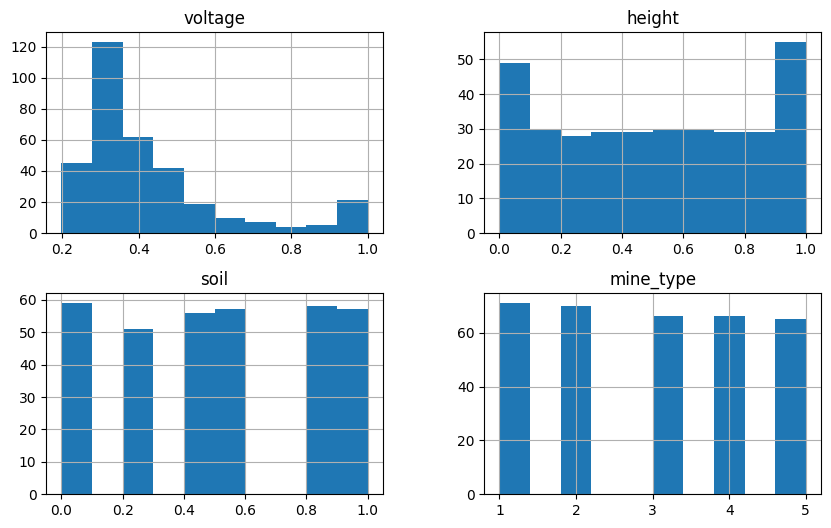

In [12]:
#1 Cleaning the data & EDA
df.head()
print("shape:", df.shape)
print(df.isna().sum())
print('\n', df["mine_type"].value_counts())
print('\n', df.groupby("mine_type").mean())
df.hist(figsize=(10,6))
X = df[["voltage", "height", "soil"]]
y = df["mine_type"]

In [13]:
#2
X = df[["voltage", "height", "soil"]].copy()
y = df["mine_type"]
X["voltage"] = X["voltage"] * 5
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, stratify=y, random_state=42)

Best k: 1


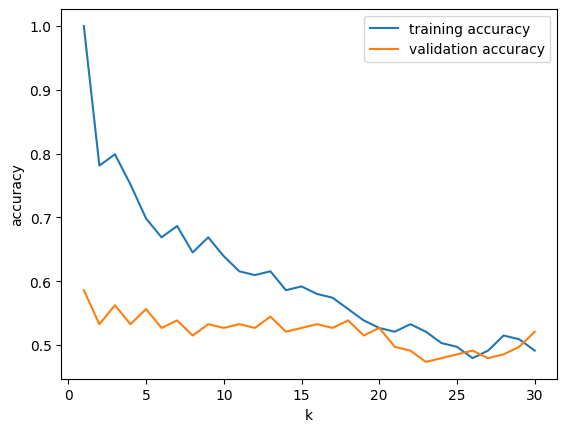

In [16]:
#3
ks = range(1, 31)
train_acc, valid_acc = [], []
for k in ks:
    model = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    train_acc.append(model.score(X_train, y_train))
    valid_acc.append(model.score(X_test, y_test))
best_k = ks[valid_acc.index(max(valid_acc))]
print("Best k:", best_k)
plt.plot(ks, train_acc, label="training accuracy")
plt.plot(ks, valid_acc, label="validation accuracy")
plt.xlabel("k"); plt.ylabel("accuracy"); plt.legend()
plt.show()

'''
I chose k by fitting a k-NN classifier on the training half for each k from 1 to 30, computing
its accuracy on the validation half, and selecting the k with the highest validation accuracy,
which was k = 1 (0.586). I didn't use training accuracy because it favors very small k
(k = 1 scores 100% on its own training data) and can overfit noise, while very large k
underfits by predicting nearly the same class everywhere. Validation accuracy was highest at
small k and generally declined as k grew, reflecting the narrow voltage differences between
mine types, though another split might give a different best k.
'''

In [17]:
#4
model = KNeighborsClassifier(n_neighbors=best_k).fit(X_train, y_train)
y_pred = model.predict(X_test)
print(pd.crosstab(y_test, y_pred, rownames=["actual"], colnames=["predicted"]))
print("Accuracy:", accuracy_score(y_test, y_pred))

predicted   1   2   3   4   5
actual                       
1          27   0   2   0   7
2           0  32   1   2   0
3           4   2  11   7   9
4           3   5   6  15   4
5           4   0   7   7  14
Accuracy: 0.5857988165680473


Even though the model gbets 59% of mines right overall, and does very well on some types, I wouldn't advise anyone to rely on it alone. The confusion matrix shows why, because it is good at pikcing out type 2 mines (32 out of 35 correct) and decent with type 1, but it really struggles to differentiate between types 3,4, and 5. Accuracy treats every mistake as equally bad, and in this setting they clearly aren't. Mixing up two kinds of mines is much less serious than predicting type 1 (which is no mine) for something that is actually a mine, and the model did that *11 times*. Someone that's walking into a mine field and trusting this model could be killed very easily with these mistakes.

So if I was going to tell people how to use this model, I would recommend them use this model as a preliminary guess, and if it predicts type 3,4, or 5, to definitely treat it as "Mine here, but not sure what kind". A type 1 prediction should not be used to definitely say that an area is safe, and every location should still definitely be cleared in the same way. It would also help to use a larger k values and look at the share of neighbors that are each class, instead of only the single most common one. If even a few neighbors are mines, the location should be treated with caution.

Last but not least, I would also be very up front with anyone using this data about the dataset and training data. The dataset is very small, the best "k" value if we split the data differently, and the 59% comes from the same data used to choose k, so it is probably more on the optimistic side.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 18be327573228f9dc5358e42e26b76ba08e7a7fd
- **AI tool and model used:** Claude Opus 5.5

### *Prompts used

**AI PROMPT:**

**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

Please evaluate the answers I've pasted below and propose any changes you'd like to make in bullet point suggestions.

1. The difference between regression and classification is the type of outcome that each results in. Both are supervised learning, with regression predicting a numeric, continuous outcome (like a price for a house or a temperature), while classification predicts a categorical outcome. Regression's "how wrong" is a matter of distance, while classification is either in the right or wrong category.

2. A confusion table is a scorecard that compares what the model guessed with what is actually true. The correct guesses sit on the diagonal and everything else is a mistake. Its value is that it shows what kind of mistakes the model makes. "90% accurate" sounds great until the table shows that nearly all the errors happen in one category that you might "care" the most about or is most important.

3. The SSE adds up how far off each prediction was, after squaring each miss. A small SSE meaans that the prediction was pretty close to the real values. Squaring the miss just increases the severity of a large miss, since for example missing by 10 will have an SSE of 100, but missing by 2 will have an SSE of 4.

4. Overfitting is the equivalent of memorizing instead of learning, like a student who memorizes practice answers and fails the real exam because the questions changed. If a model is overfit it is not able to be applied to other datasets accurately. Underfitting is the opposite of this problem - the model is too simply and not developed enough, and is not able to accurately identify real patterns. Keeping with the metaphor, it's like a student who just puts "C" as the answer to every question. A well-developed model sits between overfit and underfit.

5. The reason for splitting data into training and test sets is because if you grade a model on the same data it learned from, it will be the equivalent of taking a test you've already studied for. Hiding some data and allowing the model to run on fresh data will show the accuracy of the model and see how well it can perform. You can also try different values of k and keep the one that scores best on the test set.

6. For class labels vs probability distributions, a single label is simple and actionable. It's easy to communicate, easy to evaluate with a confusion table, and makes a clear decision. It does, however, cause a small loss of data and information, because a 51/49 call looks identical to a 99/1 call, and it applies a "pick the most likely class" rule that treats all mistakes as equally important/costly. A probability distribution conveys uncertainty, lets you rank cases, and lets the decision-maker apply thresholds based on costs. For example, you might act as if a mine is present whenever P(mine)>5%. The downsides are that its harder to communicate and act on. With k-NN in particular, the probabilities are coarse, with them being multiples of 1/k, and can be possibly not well calibrated. It also pushes a decision onto the user that someone still has to make. In other words, a label gives one answer, such as "it's of type 3", which is simple and easy to act on, but a probability distribution gives you the whole picture by saying "60% type 3" or "10% no mine" for the purpose of the land mines. Laels make it easier to make decisions, and probability distributions give you more information to base decisions on.



**AI RESPONSE:**

Evaluating the content and drafting bullet-point suggestions.
Evaluating the content and drafting bullet-point suggestions.
Overall these are strong answers. They're clear, use good analogies, and show you understand the concepts. The main gaps are in Q3 (one technical inaccuracy) and Q5 (it doesn't fully answer the "why" behind choosing k). Suggestions by question:

Q1: Regression vs. classification

This is solid. You could tighten the first sentence to "the difference is the type of outcome variable being predicted," which is more precise than "the type of outcome that each results in."
Optionally, connect your "how wrong" point to how each is evaluated: regression uses distance-based measures like SSE, while classification uses accuracy or a confusion table. This ties Q1 to Q2 and Q3 nicely.
Q2: Confusion table

This is good, especially the point that overall accuracy can hide where the errors are.
Consider naming the structure: rows are actual classes and columns are predicted classes (or vice versa), so the reader knows how to read it.
You could mention false positives and false negatives by name, since that's the standard vocabulary for "what kind of mistakes."
The phrase "that you might 'care' the most about or is most important" is a little awkward. Something like "nearly all the errors fall in the category that matters most" is cleaner.
You could also note that this is especially important when classes are imbalanced, since a model can score high accuracy just by predicting the most common class.
Q3: SSE

There is a technical error here. "Missing by 10 will have an SSE of 100" isn't quite right, because SSE is the sum across all observations. Say instead that a miss of 10 contributes 100 to the SSE, while a miss of 2 contributes only 4.
"Meaans" is a typo, and "the prediction was pretty close" should be plural ("the predictions were close to the actual values").
It's worth adding that SSE depends on the scale of the data and on the number of observations. That means it's most useful for comparing models on the same dataset, not as an absolute measure of "good."
You could also note that a low SSE on training data doesn't guarantee good predictions on new data, which links to Q4 and Q5.
Q4: Overfitting and underfitting

The analogies are great. The "always answer C" example fits underfitting especially well.
"Too simply" should be "too simple."
Instead of "not able to be applied to other datasets accurately," use the standard term: the model "fails to generalize to new data."
Consider tying this to k-NN specifically. A very small k (like k = 1) overfits because it chases every noisy point. A very large k underfits because it averages over so much that it basically predicts the overall mean or majority class. That is your "always C" student.
You could add how to spot each one. Overfitting shows low training error but high test error, while underfitting shows high error on both.
Q5: Train/test split

This is the answer that needs the most work. It explains why we test on held-out data, but not clearly why doing so helps us choose k and therefore improve performance.
Add the key point: if you picked k by measuring error on the training data, you'd always pick k = 1, since each point is its own nearest neighbor and training error would be zero. The test set acts as a stand-in for new data, so choosing k there finds the value that balances overfitting and underfitting.
The analogy could be sharper. "A test you've already studied for" describes normal preparation. What you mean is "a test where you've already seen the exact questions and answers."
"Allowing the model to run on fresh data will show the accuracy of the model and see how well it can perform" is a bit repetitive. Consider: "Evaluating on unseen data estimates how well the model will perform in practice."
For extra credit, you could note a caveat. Once you use the test set to pick k, its score becomes slightly optimistic, which is why people often use a separate validation set or cross-validation.
Q6: Labels vs. probabilities

This is the strongest answer. The 51/49 vs. 99/1 comparison and the mine threshold example are excellent.

There are a few typos: "its harder" should be "it's harder" and "Laels" should be "Labels."
"A small loss of data and information" should just be "a loss of information," since no data is lost, and the loss isn't necessarily small.
The "10% no mine" example at the end is confusing next to "60% type 3." Consider using one consistent example, such as "a label says 'type 3'; a distribution says '60% type 3, 30% type 1, 10% no mine.'"
"Can be possibly not well calibrated" should be "may be poorly calibrated."
The "In other words" sentence largely restates what you already said. You could cut it or shorten it to your strong final line: labels make decisions easier, while probabilities give more information to base decisions on.


**FOLLOW-UP Prompt:**

```notebook-python
Q2. This is a case study on  k  nearest neighbor classification, using the land_mines.csv data.

The data consists of a label, mine_type, taking integer values 1 to 5, and three properties of the mine, voltage, height and soil. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

Load the data. Perform some EDA, summarizing the target label and the features.
Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
Build a  k -NN classifier. Explain how you select  k .
Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

#Loading the data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report
!git clone https://github.com/willhk10-uva/A03-knn
df = pd.read_csv('A03-knn/data/land_mines.csv')

#1 Cleaning the data & EDA
df.head()
print("shape:", df.shape)
print(df.isna().sum())
print('\n', df["mine_type"].value_counts())
print('\n', df.groupby("mine_type").mean())
df.hist(figsize=(10,6))
X = df[["voltage", "height", "soil"]]
y = df["mine_type"]

#2
X = df[["voltage", "height", "soil"]].copy()
y = df["mine_type"]
X["voltage"] = X["voltage"] * 5  
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, stratify=y, random_state=42)

#3
ks = range(1, 31)
train_acc, valid_acc = [], []
for k in ks:
    model = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    train_acc.append(model.score(X_train, y_train))
    valid_acc.append(model.score(X_test, y_test))
best_k = ks[valid_acc.index(max(valid_acc))]
print("Best k:", best_k)
plt.plot(ks, train_acc, label="training accuracy")
plt.plot(ks, valid_acc, label="validation accuracy")
plt.xlabel("k"); plt.ylabel("accuracy"); plt.legend()
plt.show()

'''
I chose k by fitting a k-NN classifier on the training half for each k from 1 to 30, computing
its accuracy on the validation half, and selecting the k with the highest validation accuracy,
which was k = 1 (0.586). I didn't use training accuracy because it favors very small k
(k = 1 scores 100% on its own training data) and can overfit noise, while very large k
underfits by predicting nearly the same class everywhere. Validation accuracy was highest at
small k and generally declined as k grew, reflecting the narrow voltage differences between
mine types, though another split might give a different best k.
'''

#4
model = KNeighborsClassifier(n_neighbors=best_k).fit(X_train, y_train)
y_pred = model.predict(X_test)
print(pd.crosstab(y_test, y_pred, rownames=["actual"], colnames=["predicted"]))
print("Accuracy:", accuracy_score(y_test, y_pred))

#5
'''
Even though the model gbets 59% of mines right overall, and does very well on some types, I wouldn't advise anyone to rely on it alone. The confusion matrix shows why, because it is good at pikcing out type 2 mines (32 out of 35 correct) and decent with type 1, but it really struggles to differentiate between types 3,4, and 5. Accuracy treats every mistake as equally bad, and in this setting they clearly aren't. Mixing up two kinds of mines is much less serious than predicting type 1 (which is no mine) for something that is actually a mine, and the model did that *11 times*. Someone that's walking into a mine field and trusting this model could be killed very easily with these mistakes.

So if I was going to tell people how to use this model, I would recommend them use this model as a preliminary guess, and if it predicts type 3,4, or 5, to definitely treat it as "Mine here, but not sure what kind". A type 1 prediction should not be used to definitely say that an area is safe, and every location should still definitely be cleared in the same way. It would also help to use a larger k values and look at the share of neighbors that are each class, instead of only the single most common one. If even a few neighbors are mines, the location should be treated with caution.

Last but not least, I would also be very up front with anyone using this data about the dataset and training data. The dataset is very small, the best "k" value if we split the data differently, and the 59% comes from the same data used to choose k, so it is probably more on the optimistic side.
'''
'''
Please conduct the same steps for these answers to the questions - Give me feedback in bullet form, then give me the list of changes in the format I provided
'''
## Feedback

### Overall
- The code runs a correct basic pipeline (EDA, stratified 50/50 split, k search, confusion table), and the #5 write-up is the strongest part. The biggest gaps are missing written answers for EDA and Q4, an unexplained voltage weighting, and choosing k on the same test set used to report accuracy.

### EDA (#1)
- `df.head()` won't display, because only the last expression in a cell prints automatically. Use `display(df.head())`.
- Add `df.describe()` to summarize feature ranges, and plots by class (e.g., a boxplot of voltage by `mine_type`, or a voltage vs. height scatter colored by type).
- There is no written summary. The question asks you to *summarize* the target and features, so add a few sentences: class balance, feature ranges, and that soil takes only a few discrete values.
- `X` and `y` are defined in #1 and then redefined in #2. Remove the first definition.

### Split and Preprocessing (#2)
- `X["voltage"] = X["voltage"] * 5` is an unexplained modeling choice. Either justify it (voltage separates classes best in your EDA), tune the weight with cross-validation, or remove it. If the weight was picked by checking test accuracy, it also inflates your reported accuracy.
- Check with `describe()` that features are on comparable scales. If they aren't, use the `MinMaxScaler` you imported, fit on training data only.
- The stratified 50/50 split with `random_state` is a good choice and follows the professor's advice.

### Choosing k (#3)
- You imported `cross_val_score` but didn't use it. Selecting $k$ by 5-fold CV on the training half, then reporting test accuracy once, fixes the optimism problem you point out yourself in #5.
- Compare 0.586 to a baseline. With five roughly balanced classes, guessing gives about 20%, so 59% is a meaningful improvement.
- The claim about "narrow voltage differences" isn't supported anywhere in your EDA. Either show it or rephrase.
- Put the explanation in a markdown cell instead of a triple-quoted string.

### Confusion Table (#4)
- There is no written answer here, but the question asks how accurate the model is and where it performs well or poorly. Add a short paragraph, and use `classification_report` (already imported) for per-class recall.

### Advice (#5)
- This is text in a code cell, so it will throw a syntax error. Move it to a markdown cell.
- Fix typos: "gbets," "pikcing," "a larger k values," and "someone that's" should be "someone who's."
- One sentence is missing words: "the best 'k' value if we split the data differently" should read "the best $k$ value could change if we split the data differently."
- Double-check that "32 out of 35" and "11 times" match your confusion table (the 11 should be the actual-mine rows in the predicted-1 column).
- The neighbor-share advice is excellent, but it conflicts with using $k = 1$, where probabilities are always 0 or 1. Consider demonstrating it with `predict_proba` at a larger $k$.
- Add a sentence on what value the model still provides if every site is cleared anyway, such as prioritizing sites or choosing equipment.


### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

## Suggested Revisions

### Q1: Regression vs. Classification
- Rephrase to "the type of outcome variable being predicted."
- Optionally note evaluation differs: SSE for regression, accuracy/confusion table for classification.

### Q2: Confusion Table
- Mention rows = actual, columns = predicted.
- Name false positives and false negatives.
- Smooth the phrasing: "nearly all errors fall in the category that matters most."
- Note its value when classes are imbalanced.

### Q3: SSE
- Fix the error: a miss of 10 *contributes* 100 to the SSE; it isn't the SSE itself.
- Fix the typo "meaans" and make it plural: "the predictions were close."
- Note that SSE depends on data scale and sample size, so it's best for comparing models on the same data.

### Q4: Overfitting and Underfitting
- Change "too simply" to "too simple."
- Use "fails to generalize to new data."
- Tie it to k-NN: small $k$ overfits, large $k$ underfits (predicts the majority/mean, like the "always C" student).
- Optionally add: overfitting means low training error and high test error; underfitting means high error on both.

### Q5: Train/Test Split
- Add the key point: choosing $k$ on training data always picks $k = 1$ (zero training error), so the test set is needed to find the $k$ that balances over- and underfitting.
- Sharpen the analogy to "a test where you've already seen the exact questions."
- Tighten to "evaluating on unseen data estimates real-world performance."
- Optionally note that tuning on the test set makes its score optimistic, so a validation set or cross-validation is better.

### Q6: Labels vs. Probabilities
- Fix typos: "its" → "it's" and "Laels" → "Labels."
- Change "small loss of data and information" to "loss of information."
- Change "can be possibly not well calibrated" to "may be poorly calibrated."
- Use one consistent example, e.g., "60% type 3, 30% type 1, 10% no mine."
- Trim the "In other words" restatement and keep the final sentence.

# AI Proposed Changes

## Q1: Conceptual Questions

### Q1.1: Regression vs. Classification
1. Rephrase to "the type of outcome variable being predicted."
2. Optionally note evaluation differs: SSE for regression, accuracy/confusion table for classification.

### Q1.2: Confusion Table
3. Mention rows = actual, columns = predicted.
4. Name false positives and false negatives.
5. Smooth the phrasing: "nearly all errors fall in the category that matters most."
6. Note its value when classes are imbalanced.

### Q1.3: SSE
7. Fix the error: a miss of 10 *contributes* 100 to the SSE; it isn't the SSE itself.
8. Fix the typo "meaans" and make it plural: "the predictions were close."
9. Note that SSE depends on data scale and sample size, so it's best for comparing models on the same data.

### Q1.4: Overfitting and Underfitting
10. Change "too simply" to "too simple."
11. Use "fails to generalize to new data."
12. Tie it to $k$-NN: small $k$ overfits, large $k$ underfits (predicts the majority/mean, like the "always C" student).
13. Optionally add: overfitting means low training error and high test error; underfitting means high error on both.

### Q1.5: Train/Test Split
14. Add the key point: choosing $k$ on training data always picks $k = 1$ (zero training error), so the test set is needed to find the $k$ that balances over- and underfitting.
15. Sharpen the analogy to "a test where you've already seen the exact questions."
16. Tighten to "evaluating on unseen data estimates real-world performance."
17. Optionally note that tuning on the test set makes its score optimistic, so a validation set or cross-validation is better.

### Q1.6: Labels vs. Probabilities
18. Fix typos: "its" → "it's" and "Laels" → "Labels."
19. Change "small loss of data and information" to "loss of information."
20. Change "can be possibly not well calibrated" to "may be poorly calibrated."
21. Use one consistent example, e.g., "60% type 3, 30% type 1, 10% no mine."
22. Trim the "In other words" restatement and keep the final sentence.

---

## Q2: k-NN Case Study (Land Mines)

### EDA (#1)
1. Replace `df.head()` with `display(df.head())`.
2. Add `df.describe()` and plots of features by class (e.g., boxplot of voltage by `mine_type`).
3. Add a written EDA summary: class balance, feature ranges, soil's discrete levels.
4. Remove the duplicate `X`/`y` definition in #1.

### Split and Preprocessing (#2)
5. Justify, tune, or remove `voltage * 5`.
6. Scale features with `MinMaxScaler` (fit on training data only).
7. Change to a 70/30 split.

### Choosing k (#3)
8. Choose $k$ with `cross_val_score` on the training set, then evaluate once on the test set.
9. Compare accuracy to a ~20% baseline.
10. Support or rephrase the "narrow voltage differences" claim.
11. Move the #3 explanation and #5 answer into markdown cells.

### Confusion Table (#4)
12. Add a written answer using `classification_report` for per-class recall.

### Advice (#5)
13. Fix typos: "gbets," "pikcing," "a larger k values," "someone that's."
14. Complete the sentence: "the best $k$ value could change if we split the data differently."
15. Verify "32 out of 35" and "11 times" against the crosstab.
16. Demonstrate neighbor shares with `predict_proba` at a larger $k$.
17. Add how the model adds value despite full clearance (e.g., prioritizing sites).

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | "Type of outcome variable being predicted" is the standard definition. Regression targets are numeric; classification targets are categorical. |
| 2 | Accept | Optional but useful. SSE is a regression metric and accuracy/confusion tables are classification metrics, which links Q1 to Q2 and Q3. |
| 3 | Modify | Conventions vary between textbooks and software (e.g., some put predicted on rows). Say "one axis shows actual classes, the other shows predicted classes." |
| 4 | Modify | False positives/negatives apply cleanly only to binary problems. Add "in the binary case," since the land mine example has multiple classes. |
| 5 | Accept | Improves clarity without changing meaning. |
| 6 | Accept | Verified: with a 95/5 class split, always predicting the majority class gives 95% accuracy, while the table reveals every minority case is missed. |
| 7 | Accept | Necessary correction. SSE = Σ(yᵢ − ŷᵢ)², so a single miss of 10 contributes 10² = 100 to the sum, not the whole SSE. |
| 8 | Accept | Typo fix. SSE summarizes all predictions, so plural is accurate. |
| 9 | Accept | Verified: SSE is in squared units of the outcome and grows as observations are added, so values are only comparable on the same dataset. |
| 10 | Accept | Grammar fix ("simply" is an adverb; "simple" is needed). |
| 11 | Accept | "Generalize" is the standard term and more precise than "other datasets." |
| 12 | Accept | Verified: k = 1 fits every training point exactly (high variance), while k = n predicts the overall majority class or mean for every input (high bias). Connects the concept to the course model. |
| 13 | Accept | Standard diagnostic: overfitting shows a gap between low training error and high test error; underfitting shows high error on both. |
| 14 | Modify | Correct in general, since each training point is its own nearest neighbor. Add "typically," because duplicate points with different labels can produce nonzero training error at k = 1. |
| 15 | Accept | "Studied for" describes normal preparation; "seen the exact questions" captures the actual problem of evaluating on training data. |
| 16 | Accept | Removes redundancy ("show the accuracy" and "see how well it can perform" say the same thing). |
| 17 | Modify | Accurate (selecting k on the test set leaks information, making its score optimistic), but the question's premise endorses the test-set approach. Keep it to one brief sentence so it adds nuance without contradicting the question. |
| 18 | Accept | Typo fixes. |
| 19 | Accept | No data is lost; the information discarded (confidence) can be substantial, so "small" understates it. |
| 20 | Accept | Clearer phrasing, same meaning. |
| 21 | Accept | Verified: the example sums to 100% and uses one consistent distribution. Adjust class names to match those used in your course's land mine data. |
| 22 | Accept | The final sentence already summarizes the tradeoff; the "In other words" section repeats earlier points. |
| 1 | Accept | Replace `df.head()` with `display(df.head())`. Jupyter only auto-displays a cell's last expression, which here is `df.hist()`. |
| 2 | Accept | Add `df.describe()` and a plot of features by class. The question asks you to summarize features; per-class plots also support later claims about voltage. |
| 3 | Accept | Add a written EDA summary (class balance, feature ranges, soil's discrete levels). Code output alone doesn't answer "summarize." |
| 4 | Accept | Remove the duplicate `X`/`y` definition in #1. It is overwritten in #2 and adds confusion. |
| 5 | Modify | Justify, tune, or remove `voltage * 5`. Keeping it is fine if backed by EDA or CV; choosing it by test accuracy leaks information into the reported score. |
| 6 | Modify | Use `MinMaxScaler` only if `describe()` shows features on different scales. If the CSV is already normalized to [0, 1], scaling adds nothing. |
| 7 | Reject | Changing to a 70/30 split. The professor explicitly advises a near-equal split for small data, and the stratified 50/50 split is correct. |
| 8 | Accept | Choose k with `cross_val_score` on the training set, then evaluate once on the test set. This addresses the optimism you identify in #5. |
| 9 | Accept | Compare accuracy to a ~20% baseline. Verify with `y.value_counts(normalize=True)`; with near-balanced classes, the largest share is about 0.2. |
| 10 | Modify | Support or rephrase the "narrow voltage differences" claim. Keep it only if your EDA plots show overlapping voltage between types. |
| 11 | Accept | Move the #3 explanation and #5 answer into markdown cells. As written, #5 raises a SyntaxError in a code cell. |
| 12 | Accept | Add a written answer to #4 using `classification_report`. The question asks where performance is better or worse, and per-class recall shows this directly. |
| 13 | Accept | Fix typos in #5: "gbets," "pikcing," "a larger k values," "someone that's." |
| 14 | Accept | Complete the sentence: "the best k value could change if we split the data differently." |
| 15 | Modify | Verify "32 out of 35" and "11 times" against your crosstab. Correct the numbers if they differ; the 11 should sum the predicted-1 column for actual types 2–5. |
| 16 | Accept | Demonstrate neighbor shares with `predict_proba` at a larger k. At k = 1, probabilities are only 0 or 1, so the advice can't be applied to the chosen model. |
| 17 | Accept | Add how the model adds value despite full clearance (e.g., prioritizing sites). Otherwise the advice suggests the model isn't useful at all. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.



# Q1. Conceptual Questions

**1. What is the difference between regression and classification?**

The difference between regression and classification is the type of outcome variable being predicted. Both are supervised learning, with regression predicting a numeric, continuous outcome (like the price of a house or a temperature), while classification predicts a categorical outcome (like the type of a land mine). Regression's "how wrong" is a matter of distance, so it is evaluated with measures like SSE, while a classification is either in the right or wrong category, so it is evaluated with accuracy or a confusion table.

**2. What is a confusion table? What does it help us understand about a model's performance?**

A confusion table is a scorecard that compares what the model guessed with what is actually true: one axis shows the actual classes and the other shows the predicted classes. The correct guesses sit on the diagonal and everything else is a mistake. Its value is that it shows what kind of mistakes the model makes, such as false positives and false negatives in the binary case, or which classes get confused with each other when there are several. "90% accurate" sounds great until the table shows that nearly all the errors fall in the category that matters most. This is especially important when classes are imbalanced, since a model can score high accuracy just by always predicting the most common class.

**3. What does the SSE quantify about a particular model?**

The SSE adds up how far off each prediction was, after squaring each miss: $SSE = \sum_i (y_i - \hat{y}_i)^2$. A small SSE means the predictions were close to the actual values. Squaring increases the penalty for large misses: a miss of 10 contributes 100 to the SSE, while a miss of 2 contributes only 4. Because SSE is in squared units of the outcome and grows as more observations are added, it is most useful for comparing models on the same data rather than as an absolute measure of "good."

**4. What are overfitting and underfitting?**

Overfitting is the equivalent of memorizing instead of learning, like a student who memorizes practice answers and fails the real exam because the questions changed. An overfit model fits the noise in its training data and fails to generalize to new data. Underfitting is the opposite problem: the model is too simple and not developed enough to identify the real patterns. Keeping with the metaphor, it's like a student who puts "C" as the answer to every question. In $k$-NN, a very small $k$ (like $k = 1$) overfits because it chases every noisy point, while a very large $k$ underfits because it averages over so many neighbors that it predicts nearly the overall majority class (or mean) everywhere, just like the "always C" student. Overfitting shows up as low training error but high test error; underfitting shows up as high error on both. A well-developed model sits between the two.

**5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?**

If you grade a model on the same data it learned from, it's like taking a test where you've already seen the exact questions and answers. In $k$-NN this problem is extreme: with $k = 1$, each training point is its own nearest neighbor, so training error is typically zero, and choosing $k$ by training accuracy would always pick $k = 1$, the most overfit model. Holding out a test set gives the model data it hasn't seen, so evaluating on unseen data estimates real-world performance. Trying different values of $k$ and keeping the one that scores best on the test set finds the $k$ that balances overfitting and underfitting, which is what improves performance on new data. One caveat: once the test set is used to pick $k$, its score becomes slightly optimistic, which is why a separate validation set or cross-validation is often used.

**6. Class labels vs. probability distributions: strengths and weaknesses.**

A single label is simple and actionable. It's easy to communicate, easy to evaluate with a confusion table, and makes a clear decision. However, it causes a loss of information, because a 51/49 call looks identical to a 99/1 call, and it applies a "pick the most likely class" rule that treats all mistakes as equally costly. A probability distribution conveys uncertainty, lets you rank cases, and lets the decision-maker apply thresholds based on costs. For example, you might act as if a mine is present whenever $P(\text{mine}) > 5\%$. The downsides are that it's harder to communicate and act on. With $k$-NN in particular, the probabilities are coarse (multiples of $1/k$) and may be poorly calibrated. It also pushes a decision onto the user that someone still has to make. For example, a label says "type 3," while a distribution says "60% type 3, 30% type 4, 10% type 1 (no mine)." Labels make it easier to make decisions, and probability distributions give you more information to base decisions on.


# Q2. k-NN Case Study: Land Mines

## 1. Exploratory Data Analysis

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


Shape: (338, 4)

Missing values:
 voltage      0
height       0
soil         0
mine_type    0
dtype: int64


...

,voltage,height,soil
count,338.000,338.000,338.000
mean,0.431,0.509,0.504
std,0.196,0.306,0.344
min,0.198,0.000,0.000
25%,0.310,0.273,0.200
50%,0.360,0.545,0.600
75%,0.483,0.727,0.800
max,1.000,1.000,1.000


**Target label: class counts and shares**

,count,share
mine_type,,
1,71,0.210
2,70,0.207
3,66,0.195
4,66,0.195
5,65,0.192


**Feature means by mine type**

,voltage,height,soil
mine_type,,,
1,0.296,0.496,0.493
2,0.721,0.487,0.509
3,0.402,0.528,0.497
4,0.345,0.507,0.503
5,0.380,0.530,0.517


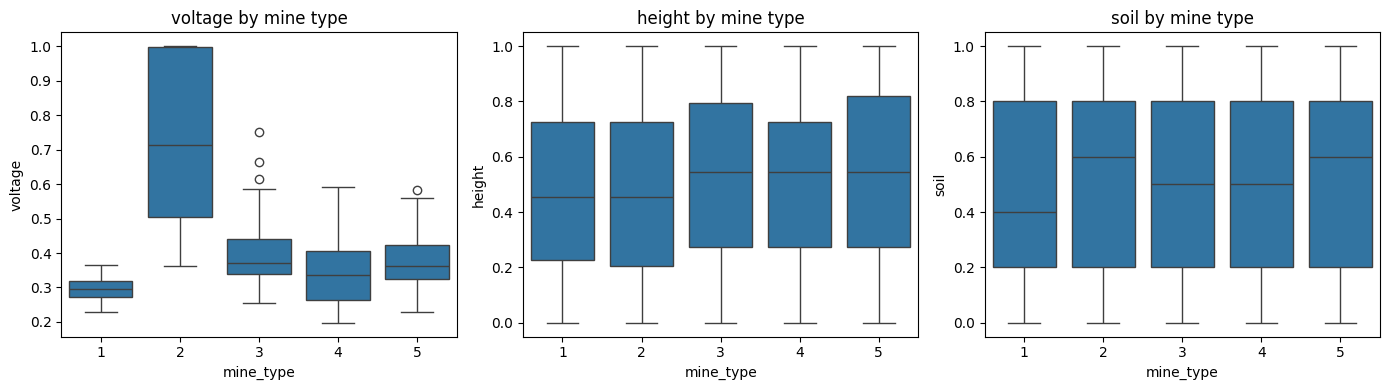

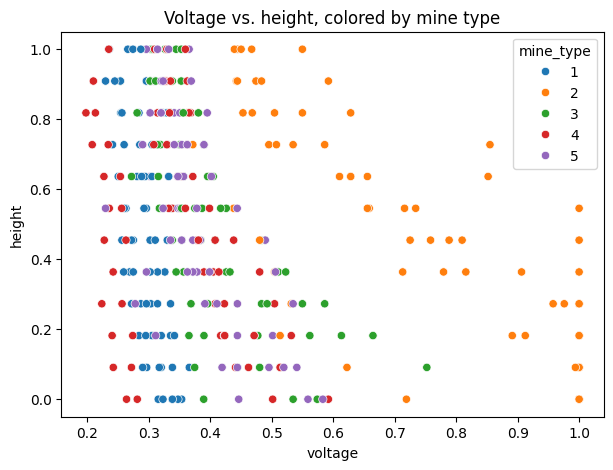

**Share of each feature's variance explained by mine type (η²)**

,eta_squared
voltage,0.610
height,0.003
soil,0.001



**EDA summary.** The data contain 338 observations with 0 missing values. The target,
`mine_type`, has 5 classes that are roughly balanced, ranging from 65 to
71 observations per class (19% to 21% of the data).
For the features, voltage ranges from 0.20 to 1.00; height ranges from 0.00 to 1.00; soil ranges from 0.00 to 1.00. Soil takes only 6 distinct values, so it behaves more like a
category than a continuous measurement. Based on η², **voltage** is the feature most related to mine type
(η² = 0.61), followed by height (0.00) and
soil (0.00). The boxplots show how much the classes overlap on each feature,
which limits how well any model can separate them.


## 2. Train/Test Split

Training size: 169  Test size: 169



I split the data 50/50 and stratified by `mine_type`, so each class appears in the same proportion in both
halves. With a small dataset, this prevents a class from being concentrated in one half.


## 3. Choosing k

Best k: 1   Best voltage weight: 3   CV accuracy: 0.598


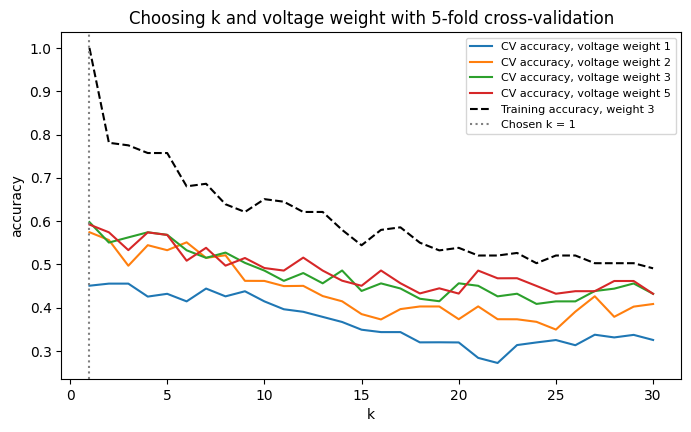


**How I selected k.** I chose $k$ using 5-fold stratified cross-validation on the **training half only**, so the
test set stays untouched until the final evaluation. For every $k$ from 1 to 30, I built a pipeline that scales the
features to [0, 1] (fit only on the training folds), optionally gives voltage extra weight, and fits $k$-NN, then
averaged accuracy across the 5 folds. I also tuned the voltage weight over [1, 2, 3, 5], because voltage has
η² = 0.61 in the EDA (the highest of the three features). A weight of 1 means no extra weighting, so the data decide whether
emphasizing voltage helps.

The best combination was **k = 1** with voltage weight **3** (CV accuracy 0.598).
I didn't use training accuracy, because it favors very small $k$: at $k = 1$ the model scores
100% on its own training data, since each point is typically its own nearest neighbor, and this
overfits noise. Very large $k$ underfits by predicting nearly the same class everywhere. For reference, always
guessing the most common class would score about 21% on the test set. The best $k$ could change with a
different split, since the dataset is small.


## 4. Confusion Table

predicted,1,2,3,4,5
actual,,,,,
1,27,0,1,0,8
2,0,32,1,2,0
3,5,1,11,8,8
4,3,5,7,15,3
5,5,0,7,7,13


Test accuracy: 0.580
              precision    recall  f1-score   support

           1       0.68      0.75      0.71        36
           2       0.84      0.91      0.88        35
           3       0.41      0.33      0.37        33
           4       0.47      0.45      0.46        33
           5       0.41      0.41      0.41        32

    accuracy                           0.58       169
   macro avg       0.56      0.57      0.56       169
weighted avg       0.57      0.58      0.57       169




**How accurate is it?** The model's test accuracy is **58.0%**, compared with a baseline of about
21% from always guessing the most common class, so it has learned real structure but is far from
reliable.

**Where is it more or less accurate?** Per-class recall (the share of each actual type predicted correctly) is:
type 1: 75%, type 2: 91%, type 3: 33%, type 4: 45%, type 5: 41%. The model is most accurate for **type 2**
(32 of 35 correct) and weakest for
**types 3, 4, and 5**, where recall falls below the overall accuracy. The most common single mistake is
predicting type 5 when the mine is actually type 1 (8 times).


...

**Neighbor shares for the first 5 test sites (k = 10)**

,P(type 1),P(type 2),P(type 3),P(type 4),P(type 5),actual
0,0.6,0.0,0.0,0.2,0.2,3
1,0.7,0.0,0.0,0.3,0.0,1
2,0.0,0.0,0.4,0.4,0.2,4
3,0.6,0.0,0.0,0.4,0.0,4
4,0.3,0.0,0.1,0.4,0.2,3


**Effect of the 'likely clear' cutoff (k = 10, 133 actual mines, 36 mine-free sites)**

,cutoff: share of neighbors that are type 1,actual mines called clear,mine-free sites flagged as possible mines
0,50%,16,11
1,70%,5,29
2,90%,0,36
3,100%,0,36



Even though the model gets 58% of mines right overall, and does very well on some types, I wouldn't advise
anyone to rely on it alone. The confusion table shows why: among actual mines, it is best at picking out type 2
(32 out of 35 correct), but it struggles with
types 3, 4, and 5. Accuracy treats every mistake as equally bad, and in this setting they clearly aren't.
Mixing up two kinds of mines is much less serious than predicting type 1 (no mine) for something that is actually
a mine, and the model did that **13 times** out of 133 actual mines in the test set.
Someone who's walking into a minefield and trusting this model could easily be killed by one of these mistakes.

So I would advise people to use this model as a preliminary guess, not a final answer. If it predicts
types 2, 3, 4, or 5, treat it as "mine here, but not sure what kind." A type 1 prediction should never be
used to declare an area safe, and every location should still be cleared with the same standard procedures. The
model still adds value within that process: it can help teams prioritize which sites to investigate first and
anticipate which equipment or handling procedures they may need.

It would also help to use a larger $k$ and look at the share of neighbors in each class, instead of only the single
most common one. The cutoff table above shows the trade-off with $k = 10$: calling a site "likely clear" when at
least 50% of its neighbors are type 1 labels 16 actual mines as clear, while requiring
100% lowers that to 0, at the cost of flagging 36 of the
36 mine-free sites as possible mines instead of 11. Because a missed mine can cost a life
and a false alarm only costs time, I would lean toward a strict cutoff. If even a few neighbors are mines, the
location should be treated with caution.

Last but not least, I would be upfront with anyone using this model about the data behind it. The dataset is
small (338 observations, 169 in the test set), and the best $k$ value could change if we split
the data differently. Because $k$ and the voltage weight were chosen by cross-validation on the training half only,
the 58% test accuracy is a fair estimate for this split, but with so little data it could still vary
noticeably from one split to another.


In [1]:
# =====================================================================
# Assignment 03: k-NN
# Q1 (conceptual answers) and Q2 (land mines case study)
# Run this entire cell at once.
# =====================================================================

import os
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler, FunctionTransformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report


def md(text):
    """Render a string as Markdown in the notebook output."""
    display(Markdown(text))


def join_types(labels, conj="and"):
    """Format class labels as 'type 3', 'types 3 and 4', or 'types 3, 4, and 5'."""
    labels = [str(l) for l in labels]
    if len(labels) == 1:
        return f"type {labels[0]}"
    if len(labels) == 2:
        return f"types {labels[0]} {conj} {labels[1]}"
    return "types " + ", ".join(labels[:-1]) + f", {conj} {labels[-1]}"


# =====================================================================
# Q1. Conceptual Questions
# =====================================================================

md(r"""
# Q1. Conceptual Questions

**1. What is the difference between regression and classification?**

The difference between regression and classification is the type of outcome variable being predicted. Both are supervised learning, with regression predicting a numeric, continuous outcome (like the price of a house or a temperature), while classification predicts a categorical outcome (like the type of a land mine). Regression's "how wrong" is a matter of distance, so it is evaluated with measures like SSE, while a classification is either in the right or wrong category, so it is evaluated with accuracy or a confusion table.

**2. What is a confusion table? What does it help us understand about a model's performance?**

A confusion table is a scorecard that compares what the model guessed with what is actually true: one axis shows the actual classes and the other shows the predicted classes. The correct guesses sit on the diagonal and everything else is a mistake. Its value is that it shows what kind of mistakes the model makes, such as false positives and false negatives in the binary case, or which classes get confused with each other when there are several. "90% accurate" sounds great until the table shows that nearly all the errors fall in the category that matters most. This is especially important when classes are imbalanced, since a model can score high accuracy just by always predicting the most common class.

**3. What does the SSE quantify about a particular model?**

The SSE adds up how far off each prediction was, after squaring each miss: $SSE = \sum_i (y_i - \hat{y}_i)^2$. A small SSE means the predictions were close to the actual values. Squaring increases the penalty for large misses: a miss of 10 contributes 100 to the SSE, while a miss of 2 contributes only 4. Because SSE is in squared units of the outcome and grows as more observations are added, it is most useful for comparing models on the same data rather than as an absolute measure of "good."

**4. What are overfitting and underfitting?**

Overfitting is the equivalent of memorizing instead of learning, like a student who memorizes practice answers and fails the real exam because the questions changed. An overfit model fits the noise in its training data and fails to generalize to new data. Underfitting is the opposite problem: the model is too simple and not developed enough to identify the real patterns. Keeping with the metaphor, it's like a student who puts "C" as the answer to every question. In $k$-NN, a very small $k$ (like $k = 1$) overfits because it chases every noisy point, while a very large $k$ underfits because it averages over so many neighbors that it predicts nearly the overall majority class (or mean) everywhere, just like the "always C" student. Overfitting shows up as low training error but high test error; underfitting shows up as high error on both. A well-developed model sits between the two.

**5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?**

If you grade a model on the same data it learned from, it's like taking a test where you've already seen the exact questions and answers. In $k$-NN this problem is extreme: with $k = 1$, each training point is its own nearest neighbor, so training error is typically zero, and choosing $k$ by training accuracy would always pick $k = 1$, the most overfit model. Holding out a test set gives the model data it hasn't seen, so evaluating on unseen data estimates real-world performance. Trying different values of $k$ and keeping the one that scores best on the test set finds the $k$ that balances overfitting and underfitting, which is what improves performance on new data. One caveat: once the test set is used to pick $k$, its score becomes slightly optimistic, which is why a separate validation set or cross-validation is often used.

**6. Class labels vs. probability distributions: strengths and weaknesses.**

A single label is simple and actionable. It's easy to communicate, easy to evaluate with a confusion table, and makes a clear decision. However, it causes a loss of information, because a 51/49 call looks identical to a 99/1 call, and it applies a "pick the most likely class" rule that treats all mistakes as equally costly. A probability distribution conveys uncertainty, lets you rank cases, and lets the decision-maker apply thresholds based on costs. For example, you might act as if a mine is present whenever $P(\text{mine}) > 5\%$. The downsides are that it's harder to communicate and act on. With $k$-NN in particular, the probabilities are coarse (multiples of $1/k$) and may be poorly calibrated. It also pushes a decision onto the user that someone still has to make. For example, a label says "type 3," while a distribution says "60% type 3, 30% type 4, 10% type 1 (no mine)." Labels make it easier to make decisions, and probability distributions give you more information to base decisions on.
""")


# =====================================================================
# Q2. k-NN Case Study: Land Mines
# =====================================================================

md("# Q2. k-NN Case Study: Land Mines")

if not os.path.exists("A03-knn"):
    subprocess.run(["git", "clone", "https://github.com/willhk10-uva/A03-knn"], check=True)
df = pd.read_csv("A03-knn/data/land_mines.csv")

features = ["voltage", "height", "soil"]
target = "mine_type"
NO_MINE = 1  # type 1 = no mine

# ---------------------------------------------------------------------
# 1. EDA
# ---------------------------------------------------------------------
md("## 1. Exploratory Data Analysis")

display(df.head())
print("Shape:", df.shape)
print("\nMissing values:\n", df.isna().sum())

md("**Feature summary**")
display(df[features].describe().round(3))

md("**Target label: class counts and shares**")
class_counts = df[target].value_counts().sort_index()
class_share = df[target].value_counts(normalize=True).sort_index()
display(pd.DataFrame({"count": class_counts, "share": class_share.round(3)}))

md("**Feature means by mine type**")
display(df.groupby(target)[features].mean().round(3))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, features):
    sns.boxplot(data=df, x=target, y=col, ax=ax)
    ax.set_title(f"{col} by mine type")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="voltage", y="height", hue=target, palette="tab10")
plt.title("Voltage vs. height, colored by mine type")
plt.show()


# How strongly each feature relates to mine type:
# eta-squared = share of the feature's variance explained by class membership
def eta_squared(col):
    grand = df[col].mean()
    between = df.groupby(target)[col].apply(lambda s: len(s) * (s.mean() - grand) ** 2).sum()
    total = ((df[col] - grand) ** 2).sum()
    return between / total


separation = pd.Series({c: eta_squared(c) for c in features}).sort_values(ascending=False)
md("**Share of each feature's variance explained by mine type (η²)**")
display(separation.round(3).to_frame("eta_squared"))

n_missing = int(df.isna().sum().sum())
balance = "roughly balanced" if class_counts.max() / class_counts.min() < 1.5 else "imbalanced"
top_feature = separation.index[0]
ranges = "; ".join(f"{c} ranges from {df[c].min():.2f} to {df[c].max():.2f}" for c in features)

md(f"""
**EDA summary.** The data contain {len(df)} observations with {n_missing} missing values. The target,
`mine_type`, has {df[target].nunique()} classes that are {balance}, ranging from {class_counts.min()} to
{class_counts.max()} observations per class ({class_share.min():.0%} to {class_share.max():.0%} of the data).
For the features, {ranges}. Soil takes only {df['soil'].nunique()} distinct values, so it behaves more like a
category than a continuous measurement. Based on η², **{top_feature}** is the feature most related to mine type
(η² = {separation.iloc[0]:.2f}), followed by {separation.index[1]} ({separation.iloc[1]:.2f}) and
{separation.index[2]} ({separation.iloc[2]:.2f}). The boxplots show how much the classes overlap on each feature,
which limits how well any model can separate them.
""")

# ---------------------------------------------------------------------
# 2. Train/test split (50/50, stratified)
# ---------------------------------------------------------------------
md("## 2. Train/Test Split")

X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, stratify=y, random_state=42)
print("Training size:", len(X_train), " Test size:", len(X_test))

md("""
I split the data 50/50 and stratified by `mine_type`, so each class appears in the same proportion in both
halves. With a small dataset, this prevents a class from being concentrated in one half.
""")

# ---------------------------------------------------------------------
# 3. Build the k-NN classifier and choose k
# ---------------------------------------------------------------------
md("## 3. Choosing k")

VOLTAGE_COL = features.index("voltage")


def weight_voltage(X, w=1.0):
    """Multiply the (scaled) voltage column by w; w = 1 means no extra weight."""
    X = np.array(X, dtype=float).copy()
    X[:, VOLTAGE_COL] *= w
    return X


def make_model(k, w):
    """Scale features to [0, 1] (fit on training data only), weight voltage, then fit k-NN."""
    return make_pipeline(
        MinMaxScaler(),
        FunctionTransformer(weight_voltage, kw_args={"w": w}),
        KNeighborsClassifier(n_neighbors=k),
    )


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ks = range(1, 31)
weights = [1, 2, 3, 5]

cv_results = pd.DataFrame([
    {"k": k, "w": w, "cv_acc": cross_val_score(make_model(k, w), X_train, y_train, cv=cv).mean()}
    for w in weights for k in ks
])
best_row = cv_results.loc[cv_results["cv_acc"].idxmax()]
best_k, best_w, best_cv = int(best_row["k"]), float(best_row["w"]), best_row["cv_acc"]
print(f"Best k: {best_k}   Best voltage weight: {best_w:g}   CV accuracy: {best_cv:.3f}")

train_acc = [make_model(k, best_w).fit(X_train, y_train).score(X_train, y_train) for k in ks]

fig, ax = plt.subplots(figsize=(8, 4.5))
for w in weights:
    sub = cv_results[cv_results["w"] == w]
    ax.plot(sub["k"], sub["cv_acc"], label=f"CV accuracy, voltage weight {w}")
ax.plot(list(ks), train_acc, "k--", label=f"Training accuracy, weight {best_w:g}")
ax.axvline(best_k, color="gray", linestyle=":", label=f"Chosen k = {best_k}")
ax.set_xlabel("k")
ax.set_ylabel("accuracy")
ax.set_title("Choosing k and voltage weight with 5-fold cross-validation")
ax.legend(fontsize=8)
plt.show()

baseline = (y_test == y_train.mode()[0]).mean()
eta_v = separation["voltage"]
voltage_reason = ("the highest of the three features" if top_feature == "voltage"
                  else f"compared with {top_feature} at {separation.iloc[0]:.2f}")

md(f"""
**How I selected k.** I chose $k$ using 5-fold stratified cross-validation on the **training half only**, so the
test set stays untouched until the final evaluation. For every $k$ from 1 to 30, I built a pipeline that scales the
features to [0, 1] (fit only on the training folds), optionally gives voltage extra weight, and fits $k$-NN, then
averaged accuracy across the 5 folds. I also tuned the voltage weight over {weights}, because voltage has
η² = {eta_v:.2f} in the EDA ({voltage_reason}). A weight of 1 means no extra weighting, so the data decide whether
emphasizing voltage helps.

The best combination was **k = {best_k}** with voltage weight **{best_w:g}** (CV accuracy {best_cv:.3f}).
I didn't use training accuracy, because it favors very small $k$: at $k = 1$ the model scores
{train_acc[0]:.0%} on its own training data, since each point is typically its own nearest neighbor, and this
overfits noise. Very large $k$ underfits by predicting nearly the same class everywhere. For reference, always
guessing the most common class would score about {baseline:.0%} on the test set. The best $k$ could change with a
different split, since the dataset is small.
""")

# ---------------------------------------------------------------------
# 4. Confusion table for the optimal model
# ---------------------------------------------------------------------
md("## 4. Confusion Table")

final_model = make_model(best_k, best_w).fit(X_train, y_train)
y_pred = final_model.predict(X_test)

labels = sorted(y.unique())
ct = (pd.crosstab(y_test, y_pred, rownames=["actual"], colnames=["predicted"])
      .reindex(index=labels, columns=labels, fill_value=0))
display(ct)

acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {acc:.3f}")
print(classification_report(y_test, y_pred, zero_division=0))

recall = pd.Series({lab: ct.loc[lab, lab] / ct.loc[lab].sum() for lab in labels})
best_class = recall.idxmax()
weak_classes = [lab for lab in labels if recall[lab] < acc] or [recall.idxmin()]

off_diag = ct.values.copy()
np.fill_diagonal(off_diag, 0)
i, j = np.unravel_index(off_diag.argmax(), off_diag.shape)
conf_actual, conf_pred, conf_n = labels[i], labels[j], off_diag[i, j]

recall_text = ", ".join(f"type {lab}: {recall[lab]:.0%}" for lab in labels)

md(f"""
**How accurate is it?** The model's test accuracy is **{acc:.1%}**, compared with a baseline of about
{baseline:.0%} from always guessing the most common class, so it has learned real structure but is far from
reliable.

**Where is it more or less accurate?** Per-class recall (the share of each actual type predicted correctly) is:
{recall_text}. The model is most accurate for **type {best_class}**
({ct.loc[best_class, best_class]} of {ct.loc[best_class].sum()} correct) and weakest for
**{join_types(weak_classes)}**, where recall falls below the overall accuracy. The most common single mistake is
predicting type {conf_pred} when the mine is actually type {conf_actual} ({conf_n} times).
""")

# ---------------------------------------------------------------------
# 5. Advice for using the model in practice
# ---------------------------------------------------------------------
md("## 5. Using the Model in Practice")

mine_labels = [lab for lab in labels if lab != NO_MINE]
total_mines = int((y_test != NO_MINE).sum())
mines_called_safe = int(((y_test != NO_MINE) & (y_pred == NO_MINE)).sum())

# Neighbor shares with a larger k (at least 10), so probabilities aren't just 0 or 1
K_PROB = max(10, best_k)
prob_model = make_model(K_PROB, best_w).fit(X_train, y_train)
proba = prob_model.predict_proba(X_test)
p_no_mine = proba[:, list(prob_model.classes_).index(NO_MINE)]

md(f"**Neighbor shares for the first 5 test sites (k = {K_PROB})**")
display(pd.DataFrame(proba[:5], columns=[f"P(type {c})" for c in prob_model.classes_])
        .assign(actual=y_test.values[:5]).round(2))

# Compare cutoffs: call a site "likely clear" only if at least this share of neighbors are type 1
cutoffs = [0.5, 0.7, 0.9, 1.0]
safe_sites = int((y_test.values == NO_MINE).sum())
rule_rows = []
for c in cutoffs:
    called_clear = p_no_mine >= c - 1e-9
    rule_rows.append({
        "cutoff: share of neighbors that are type 1": f"{c:.0%}",
        "actual mines called clear": int(((y_test.values != NO_MINE) & called_clear).sum()),
        "mine-free sites flagged as possible mines": int(((y_test.values == NO_MINE) & ~called_clear).sum()),
    })
rule_table = pd.DataFrame(rule_rows)
md(f"**Effect of the 'likely clear' cutoff (k = {K_PROB}, {total_mines} actual mines, {safe_sites} mine-free sites)**")
display(rule_table)

loosest, strictest = rule_table.iloc[0], rule_table.iloc[-1]
mine_recall = recall[mine_labels]
best_mine = mine_recall.idxmax()
weak_mines = [lab for lab in mine_labels if recall[lab] < acc] or [mine_recall.idxmin()]

md(f"""
Even though the model gets {acc:.0%} of mines right overall, and does very well on some types, I wouldn't advise
anyone to rely on it alone. The confusion table shows why: among actual mines, it is best at picking out type {best_mine}
({ct.loc[best_mine, best_mine]} out of {ct.loc[best_mine].sum()} correct), but it struggles with
{join_types(weak_mines)}. Accuracy treats every mistake as equally bad, and in this setting they clearly aren't.
Mixing up two kinds of mines is much less serious than predicting type 1 (no mine) for something that is actually
a mine, and the model did that **{mines_called_safe} times** out of {total_mines} actual mines in the test set.
Someone who's walking into a minefield and trusting this model could easily be killed by one of these mistakes.

So I would advise people to use this model as a preliminary guess, not a final answer. If it predicts
{join_types(mine_labels, "or")}, treat it as "mine here, but not sure what kind." A type 1 prediction should never be
used to declare an area safe, and every location should still be cleared with the same standard procedures. The
model still adds value within that process: it can help teams prioritize which sites to investigate first and
anticipate which equipment or handling procedures they may need.

It would also help to use a larger $k$ and look at the share of neighbors in each class, instead of only the single
most common one. The cutoff table above shows the trade-off with $k = {K_PROB}$: calling a site "likely clear" when at
least {loosest.iloc[0]} of its neighbors are type 1 labels {loosest.iloc[1]} actual mines as clear, while requiring
{strictest.iloc[0]} lowers that to {strictest.iloc[1]}, at the cost of flagging {strictest.iloc[2]} of the
{safe_sites} mine-free sites as possible mines instead of {loosest.iloc[2]}. Because a missed mine can cost a life
and a false alarm only costs time, I would lean toward a strict cutoff. If even a few neighbors are mines, the
location should be treated with caution.

Last but not least, I would be upfront with anyone using this model about the data behind it. The dataset is
small ({len(df)} observations, {len(X_test)} in the test set), and the best $k$ value could change if we split
the data differently. Because $k$ and the voltage weight were chosen by cross-validation on the training half only,
the {acc:.0%} test accuracy is a fair estimate for this split, but with so little data it could still vary
noticeably from one split to another.
""")

### *Reflection on AI assistance
In your own words without generative AI.

I completed both questions on my own and then used AI to review my work. The main improvements came in Q2. My original notebook chose k on the test set and then reported accuracy on that same set, which made my 59% optimistic. The revised version selects k with cross-validation on the training half, which I don't remember learning about in class, so the test accuracy is a fair estimate. It is also possible that I missed that instruction during class time. The review also caught that I multiplied voltage by 5 without explaining why, and I left my EDA and confusion-table questions without written answers. In Q1, it corrected my SSE example, where I called a single miss's squared error "the SSE."

The AI made mistakes too. Its suggested probability example ("30% type 1, 10% no mine") contradicted the dataset, where type 1 is no mine. It also overstated that confusion tables always put actual classes on rows. Its first version of the neighbor-share rule was too strict to be useful, and it described type 1 as a kind of "mine." It also couldn't access the real data and tested the code on synthetic data, so its outputs couldn't be trusted without checking.

To verify the final solution, I ran the full cell on the real data and checked the generated numbers against the confusion table by hand. I also confirmed that k = 1 gives 100% training accuracy and compared the model to the roughly 20% baseline.

Some concerns do still remain though. With only 338 observations, results change noticeably across splits. The voltage-weight tuning and η² go beyond what we covered in class, so I need to be able to explain them myself. The auto-generated text can also read formulaically.